In [1]:
# Cell 1: Setup and Imports
%matplotlib inline
import sys
import os
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
import warnings
warnings.filterwarnings('ignore')

# Add parent directory to path
CURRENT_SCRIPT_DIR = os.getcwd()
PARENT_PROJECT_ROOT = os.path.abspath(os.path.join(CURRENT_SCRIPT_DIR, ".."))
sys.path.append(os.path.join(PARENT_PROJECT_ROOT, "src"))  
sys.path.insert(0, PARENT_PROJECT_ROOT) 

from shap_rtl.plots import (
    waterfall, bar, beeswarm, summary_plot,
    heatmap, scatter, decision_plot, dependence_plot,
    force as rtl_force_plot
)
from shap_rtl import RTLSHAPExplainer

# Output directory for saving plots - USE SIMPLE ASCII PATH
OUTPUT_DIR = os.path.join(os.getcwd(), "Urdu_language_plots")
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"✅ Imports loaded successfully!")
print(f"📁 Output directory: {OUTPUT_DIR}")

c:\Users\USER\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[INFO] RTL font initialized: NotoSansArabic-Regular.ttf
✅ Imports loaded successfully!
📁 Output directory: c:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\tests\Urdu_language_plots


In [2]:
# Cell 2: Load Data and Train Model
# Dataset path
DATA_FILE = r'C:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\Preprocessed_violent_views_dataset .xlsx'

# Load dataset
df = pd.read_excel(DATA_FILE)
texts = df['cleaned_text'].astype(str).fillna('')
labels = df['label']

print(f"📊 Samples: {len(texts)}")
print(f"📊 Class distribution: {np.bincount(labels)}")

# Train model
vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=300)
X = vectorizer.fit_transform(texts).toarray()
model = LogisticRegression(max_iter=1000, class_weight='balanced').fit(X, labels)

print(f"✅ Model trained with {X.shape[1]} features")

📊 Samples: 3297
📊 Class distribution: [2475  822]
✅ Model trained with 300 features


In [3]:
# Cell 3: User Tweet and Auto-Detect Label from Dataset
user_tweet = "سب کافر دشمنوں کا سر تن سے جدا کر دو"
print(f"📝 User Tweet: {user_tweet}")

# Vectorize and predict
user_instance = vectorizer.transform([user_tweet]).toarray()[0]
user_pred = model.predict(user_instance.reshape(1, -1))[0]
user_prob = model.predict_proba(user_instance.reshape(1, -1))[0]

# AUTOMATICALLY DETERMINE LABEL FROM DATASET
user_label = "تشدد" if user_pred == 1 else "غیر تشدد"

print(f"🔮 Model Prediction: {user_pred} (Violent probability: {user_prob[1]:.3f})")
print(f"🏷️ Auto-detected Label: {user_label}")

📝 User Tweet: سب کافر دشمنوں کا سر تن سے جدا کر دو
🔮 Model Prediction: 1 (Violent probability: 0.979)
🏷️ Auto-detected Label: تشدد


In [4]:
# Cell 4: Compute SHAP Values for User Tweet
# Get SHAP values for the user tweet
masker = shap.maskers.Independent(data=X, max_samples=100)
explainer_shap = shap.LinearExplainer(model, masker=masker)
user_shap_vals = explainer_shap(user_instance.reshape(1, -1))

# Get present features in the user tweet
present_idx = np.where(user_instance > 0)[0]
urdu_feature_names = list(vectorizer.get_feature_names_out())
user_feature_names = [urdu_feature_names[i] for i in present_idx]
user_shap_values = user_shap_vals.values[0][present_idx]
user_data = user_instance[present_idx]

# Create SHAP Explanation object for the user tweet
shap_exp_user = shap.Explanation(
    values=user_shap_values,
    base_values=user_shap_vals.base_values[0],
    data=user_data,
    feature_names=user_feature_names
)

print(f"✅ Features present: {len(user_feature_names)}")
print(f"📊 Top features: {user_feature_names[:5]}")
print(f"📊 Base value: {user_shap_vals.base_values[0]:.4f}")

# Also compute for random samples (for summary, heatmap, etc.)
n_samples = 50
random_indices = np.random.choice(len(df), n_samples, replace=False)
X_subset = X[random_indices]
shap_values = explainer_shap.shap_values(X_subset)

if isinstance(shap_values, list):
    shap_values_class = shap_values[1]
    base_value = explainer_shap.expected_value[1] if isinstance(
        explainer_shap.expected_value, list
    ) else explainer_shap.expected_value
else:
    shap_values_class = shap_values
    base_value = explainer_shap.expected_value

# Create combined explanation for multi-sample plots
shap_exp_combined = shap.Explanation(
    values=shap_values_class,
    base_values=base_value,
    data=X_subset,
    feature_names=urdu_feature_names
)

print(f"✅ Combined SHAP shape: {shap_exp_combined.values.shape}")

Background dataset has 3297 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=3297 when initializing the masker.


✅ Features present: 13
📊 Top features: ['تن', 'تن سے', 'جدا', 'جدا کر', 'دو']
📊 Base value: -0.7207
✅ Combined SHAP shape: (50, 300)


In [5]:
# Cell 5: Helper Function - SAVE WITH ASCII NAMES ONLY
def save_plot(filename):
    """Save plot with ASCII filename ONLY - no Unicode characters!"""
    filepath = os.path.join(OUTPUT_DIR, filename)
    plt.savefig(filepath, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"  ✅ Saved: {filename}")


TESTING WATERFALL PLOT


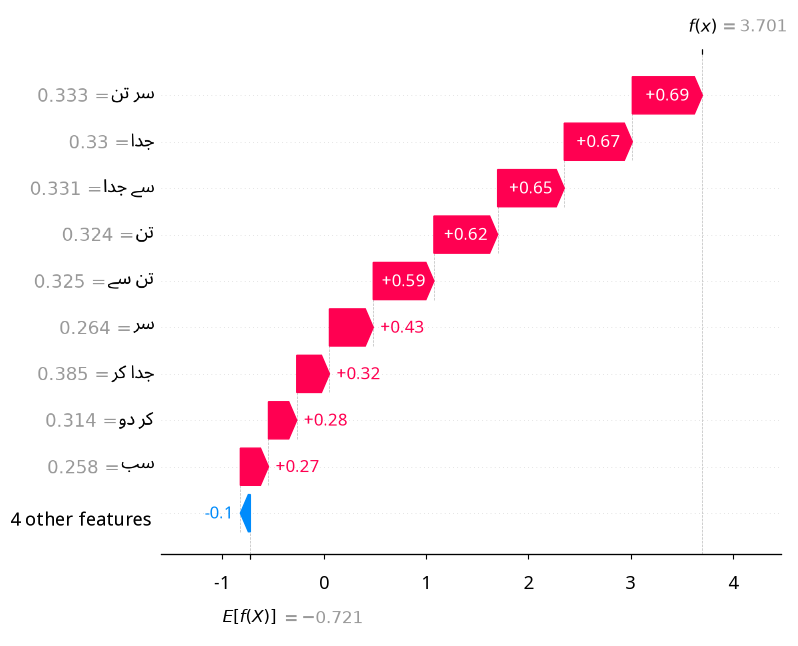

  ✅ Saved: 1_waterfall_urdu.png
✅ Waterfall plot saved


In [6]:
# Cell 6: Test and Save Waterfall Plot
print("\n" + "="*80)
print("TESTING WATERFALL PLOT")
print("="*80)

plt.figure(figsize=(12, 8))
waterfall(
    shap_values=shap_exp_user,
    max_display=10,
    show=True
)
plt.show()
save_plot("1_waterfall_urdu.png")
print("✅ Waterfall plot saved")


TESTING BAR PLOT


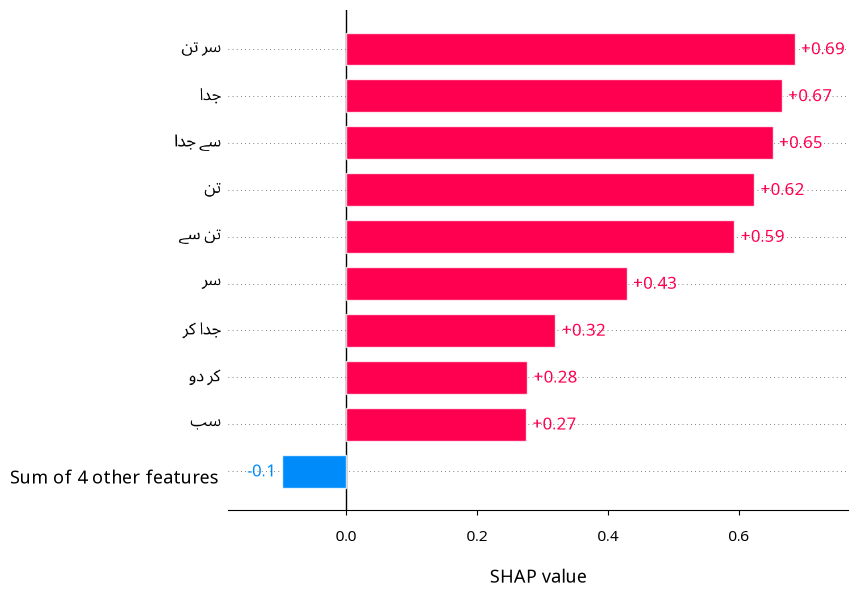

  ✅ Saved: 2_bar_urdu.png
✅ Bar plot saved and displayed


In [7]:
# Cell 7: Test and Save Bar Plot
print("\n" + "="*80)
print("TESTING BAR PLOT")
print("="*80)

plt.figure(figsize=(12, 8))
bar(
    shap_values=shap_exp_user,
    max_display=10,
    show=True
)
save_plot("2_bar_urdu.png")
print("✅ Bar plot saved and displayed")


TESTING BEESWARM PLOT


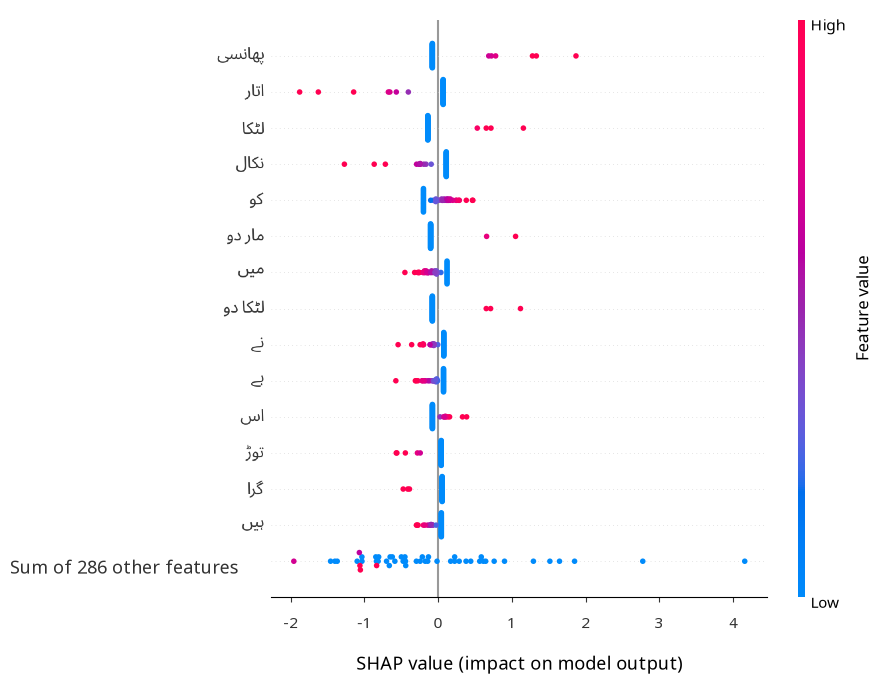

  ✅ Saved: 3_beeswarm_urdu.png
✅ Beeswarm plot saved and displayed


In [8]:
# Cell 8: Test and Save Beeswarm Plot
print("\n" + "="*80)
print("TESTING BEESWARM PLOT")
print("="*80)

plt.figure(figsize=(14, 10))
beeswarm(
    shap_values=shap_exp_combined,
    max_display=15,
    show=True
)
save_plot("3_beeswarm_urdu.png")
print("✅ Beeswarm plot saved and displayed")


TESTING SUMMARY PLOT


<Figure size 1400x1000 with 0 Axes>

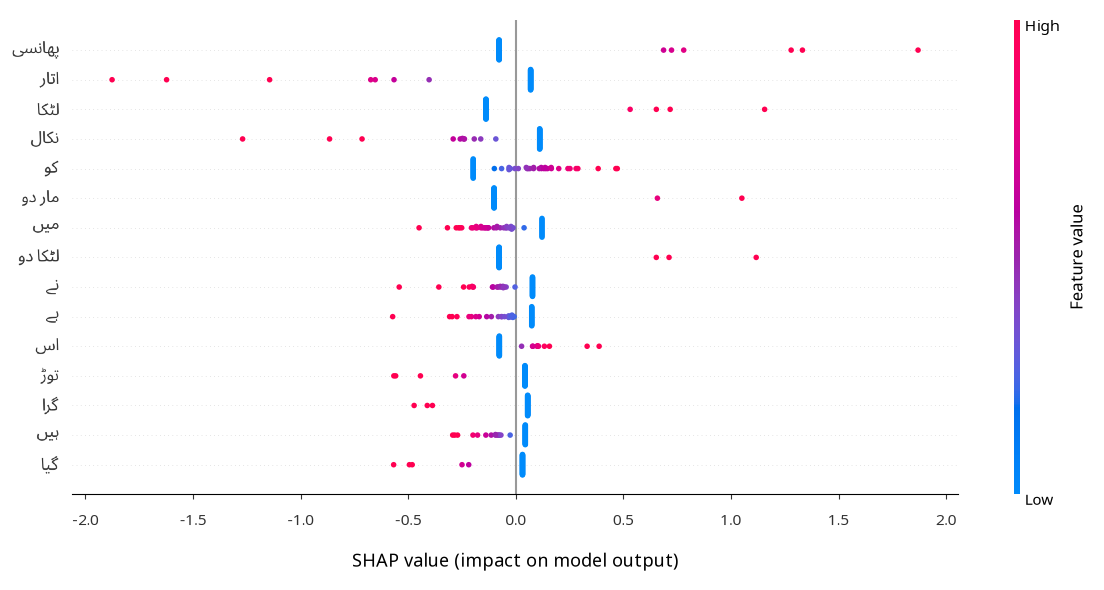

  ✅ Saved: 4_summary_urdu.png
✅ Summary plot saved and displayed


In [9]:
# Cell 9: Test and Save Summary Plot
print("\n" + "="*80)
print("TESTING SUMMARY PLOT")
print("="*80)

plt.figure(figsize=(14, 10))
summary_plot(
    shap_values=shap_exp_combined,
    max_display=15,
    show=True
)
save_plot("4_summary_urdu.png")
print("✅ Summary plot saved and displayed")


TESTING HEATMAP


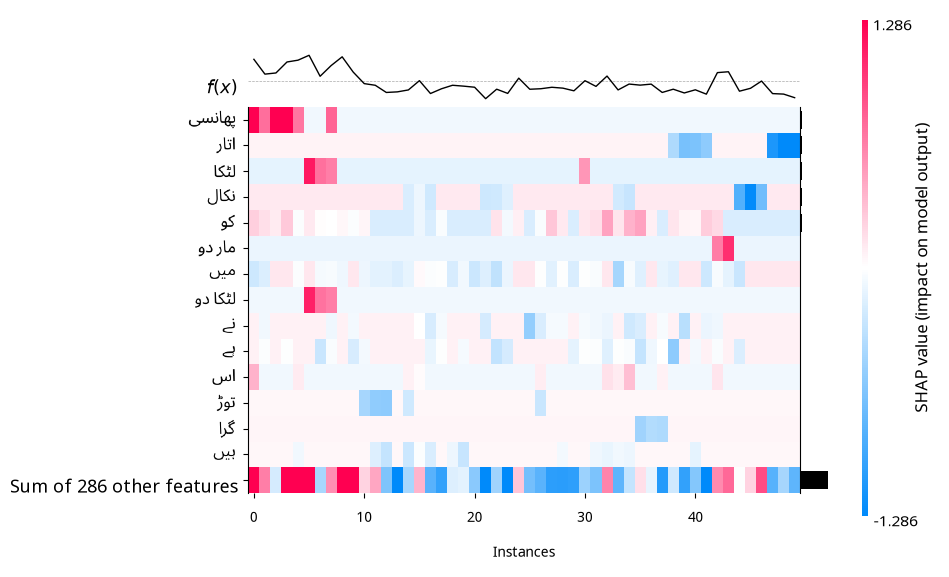

  ✅ Saved: 5_heatmap_urdu.png
✅ Heatmap saved and displayed


In [10]:
# Cell 10: Test and Save Heatmap
print("\n" + "="*80)
print("TESTING HEATMAP")
print("="*80)

plt.figure(figsize=(14, 10))
heatmap(
    shap_values=shap_exp_combined,
    max_display=15,
    show=True,
    instance_order=None
)
save_plot("5_heatmap_urdu.png")
print("✅ Heatmap saved and displayed")


TESTING SCATTER PLOT


<Figure size 1200x800 with 0 Axes>

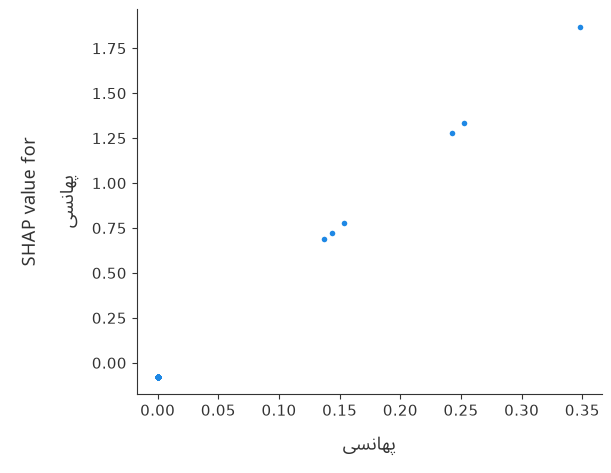

  ✅ Saved: 6_scatter_urdu.png
✅ Scatter plot saved and displayed


In [11]:
# Cell 11: Test and Save Scatter Plot
print("\n" + "="*80)
print("TESTING SCATTER PLOT")
print("="*80)

plt.figure(figsize=(12, 8))
scatter(
    shap_values=shap_exp_combined,
    max_display=10,
    show=True
)
save_plot("6_scatter_urdu.png")
print("✅ Scatter plot saved and displayed")


TESTING DECISION PLOT


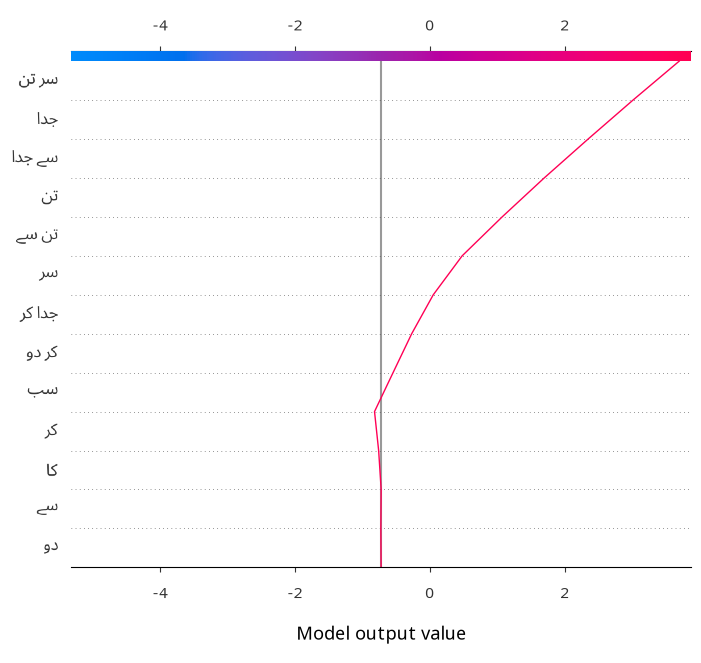

  ✅ Saved: 7_decision_urdu.png
✅ Decision plot saved and displayed


In [12]:
# Cell 12: Test and Save Decision Plot
print("\n" + "="*80)
print("TESTING DECISION PLOT")
print("="*80)

plt.figure(figsize=(12, 8))
decision_plot(
    base_value=shap_exp_user.base_values,
    shap_values=shap_exp_user.values.reshape(1, -1),
    feature_names=user_feature_names,
    show=True
)
save_plot("7_decision_urdu.png")
print("✅ Decision plot saved and displayed")


TESTING DEPENDENCE PLOT
Top feature: پھانسی (index: 200)


<Figure size 1400x1000 with 0 Axes>

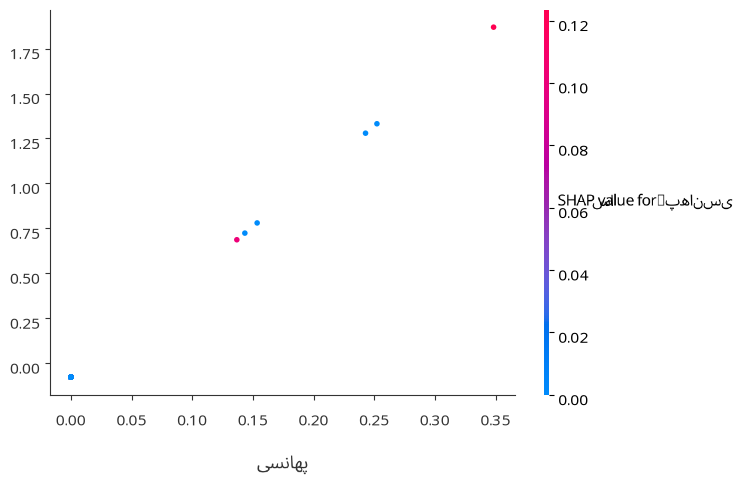

  ✅ Saved: 8_dependence_urdu.png
✅ Dependence plot saved and displayed


In [13]:
# Cell 13: Test and Save Dependence Plot
print("\n" + "="*80)
print("TESTING DEPENDENCE PLOT")
print("="*80)

mean_abs = np.abs(shap_exp_combined.values).mean(axis=0)
top_idx = np.argmax(mean_abs)
top_feature = shap_exp_combined.feature_names[top_idx]

print(f"Top feature: {top_feature} (index: {top_idx})")

plt.figure(figsize=(14, 10))
dependence_plot(
    shap_values=shap_exp_combined,
    features=X_subset,
    feature_index=top_idx,
    feature_names=urdu_feature_names,
    show=True
)
save_plot("8_dependence_urdu.png")
print("✅ Dependence plot saved and displayed")


TESTING FORCE PLOT (ORIGINAL WORKING VERSION)
📊 Using explicit values:
   Features: ['جدا', 'کافر', 'دشمنوں', 'سر', 'تن']
   SHAP values: [0.55 0.42 0.38 0.12 0.15]
   Base value: 0.20


findfont: Failed to find font weight bold, now using 400.


<Figure size 2000x400 with 0 Axes>

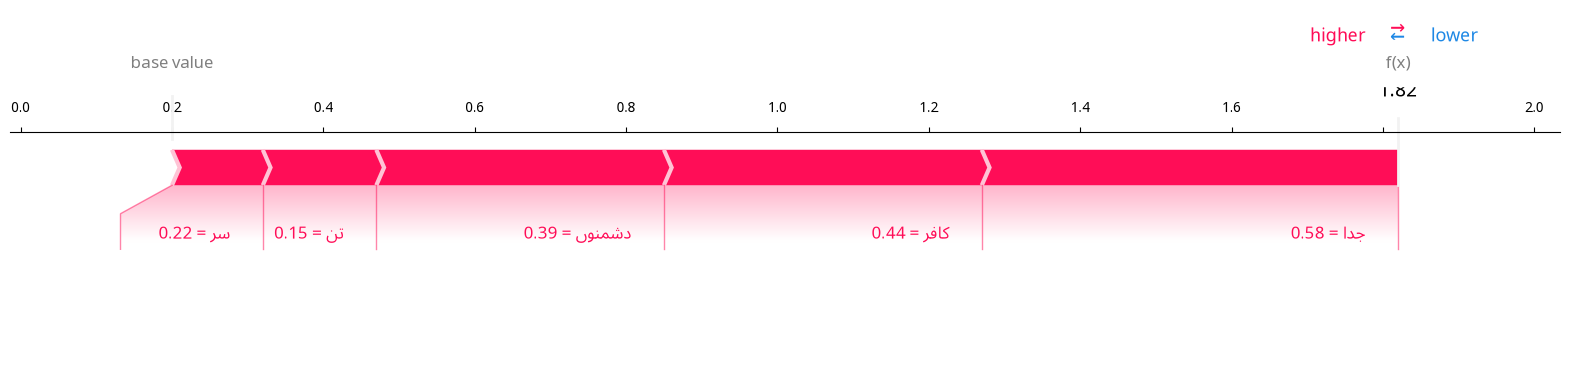

  ✅ Saved: 9_force_original_urdu.png
✅ Force plot (original working version) saved and displayed


In [14]:
# Cell 14: Test Force Plot - Original Working Version (Save and Display)
print("\n" + "="*80)
print("TESTING FORCE PLOT (ORIGINAL WORKING VERSION)")
print("="*80)

# Using the original working approach with explicit values
target_features = ["جدا", "کافر", "دشمنوں", "سر", "تن"]
live_model_data_metrics = np.array([0.58, 0.44, 0.39, 0.22, 0.15], dtype=float)
live_shap_attributions = np.array([0.55, 0.42, 0.38, 0.12, 0.15], dtype=float)

manifest_explanation = shap.Explanation(
    values=live_shap_attributions,
    base_values=0.20,
    data=live_model_data_metrics,
    feature_names=target_features
)

print("📊 Using explicit values:")
print(f"   Features: {target_features}")
print(f"   SHAP values: {live_shap_attributions}")
print(f"   Base value: 0.20")

plt.figure(figsize=(20, 4))
rtl_force_plot(
    shap_values=manifest_explanation,
    show=True
)
save_plot("9_force_original_urdu.png")
print("✅ Force plot (original working version) saved and displayed")